In [1]:
import os
import pandas as pd
from data.sofr import get_sofr_data
from data.ratings import get_effective_yield, get_yield_curve

fred_api_key = os.getenv("FRED_API_KEY")

In [2]:
sofr = get_sofr_data(api_key=fred_api_key, frequency='Q', end_date='2028-06-30')
sofr

,date,sofr,rate_status
0,2028-06-30,0.0365,assumed
1,2028-03-31,0.0365,assumed
2,2027-12-31,0.0365,assumed
3,2027-09-30,0.0365,assumed
4,2027-06-30,0.0365,assumed
5,2027-03-31,0.0365,assumed
6,2026-12-31,0.0365,assumed
7,2026-09-30,0.0365,assumed
8,2026-06-30,0.0365,assumed
9,2026-03-31,0.0368,actual


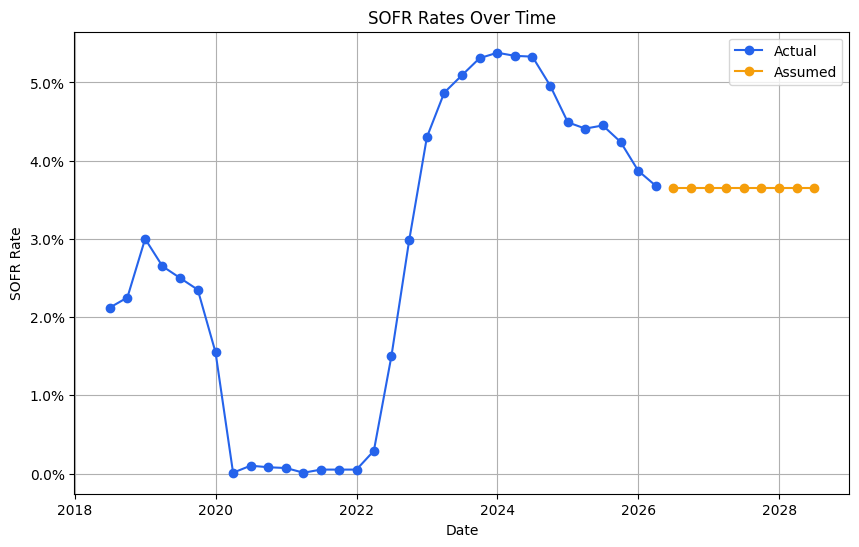

In [3]:
# chart sofr data
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

plot_df = sofr.sort_values('date').copy()
status_colors = {
    'actual': '#2563eb',
    'assumed': '#f59e0b',
}

plt.figure(figsize=(10, 6))
for rate_status, group in plot_df.groupby('rate_status', sort=False):
    plt.plot(
        group['date'],
        group['sofr'],
        marker='o',
        linestyle='-',
        color=status_colors.get(rate_status, '#6b7280'),
        label=rate_status.title(),
    )

plt.title('SOFR Rates Over Time')
plt.xlabel('Date')
plt.ylabel('SOFR Rate')
plt.gca().yaxis.set_major_formatter(PercentFormatter(xmax=1.0))
plt.legend()
plt.grid()
plt.show()

In [4]:
CCC = get_effective_yield(rating="CCC", api_key=fred_api_key, frequency="Q", end_date='2028-06-30')
CCC

,date,effective_yield,yield_status
0,2028-06-30,0.1372,assumed
1,2028-03-31,0.1372,assumed
2,2027-12-31,0.1372,assumed
3,2027-09-30,0.1372,assumed
4,2027-06-30,0.1372,assumed
...,...,...,...
122,1997-12-31,0.1307,actual
123,1997-09-30,0.1201,actual
124,1997-06-30,0.1329,actual
125,1997-03-31,0.1369,actual


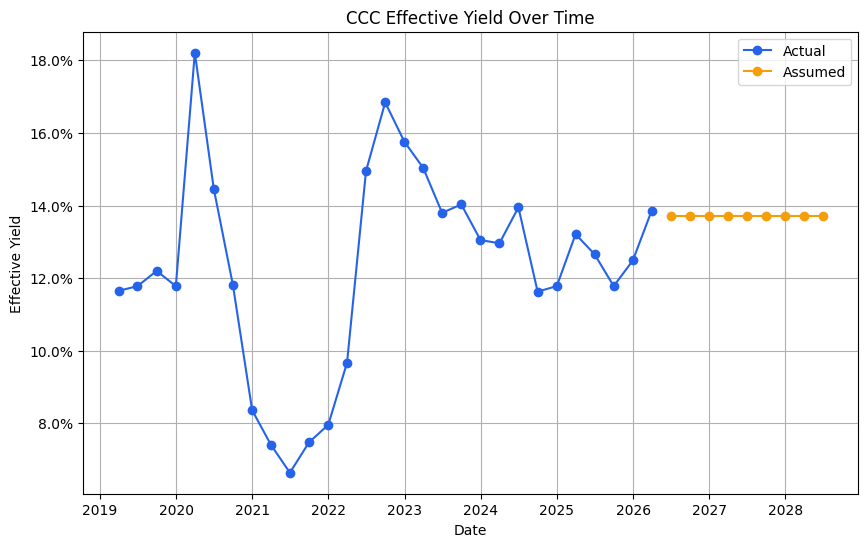

In [5]:
plot_df = CCC.loc[CCC['date'] >= '2019-01-01'].sort_values('date').copy()
status_colors = {
    'actual': '#2563eb',
    'assumed': '#f59e0b',
}

plt.figure(figsize=(10, 6))
for rate_status, group in plot_df.groupby('yield_status', sort=False):
    plt.plot(
        group['date'],
        group['effective_yield'],
        marker='o',
        linestyle='-',
        color=status_colors.get(rate_status, '#6b7280'),
        label=rate_status.title(),
    )

plt.title('CCC Effective Yield Over Time')
plt.xlabel('Date')
plt.ylabel('Effective Yield')
plt.gca().yaxis.set_major_formatter(PercentFormatter(xmax=1.0))
plt.legend()
plt.grid()
plt.show()

In [6]:
yield_curve = get_yield_curve(fred_api_key)

In [7]:
max_date = yield_curve['date'].max()

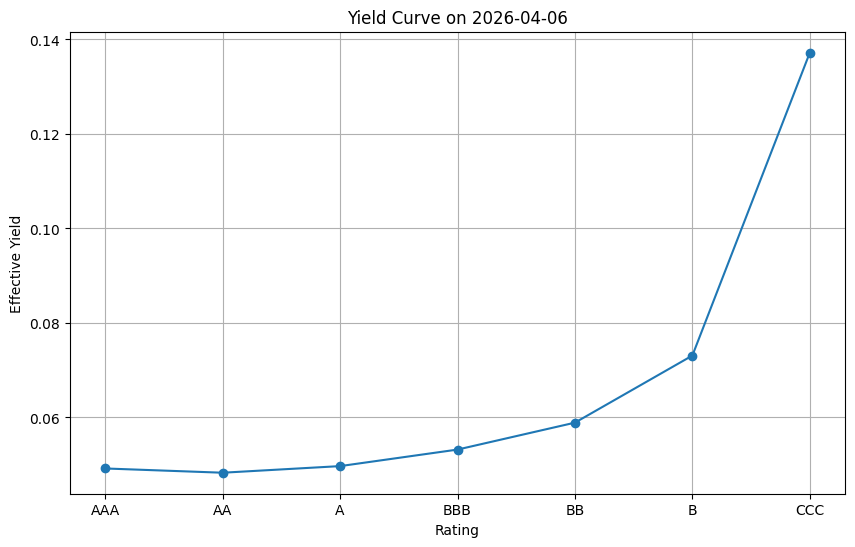

In [9]:
# plot yield curve where date == max_date, order the x axis by rating
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
ratings_order = ["AAA", "AA", "A", "BBB", "BB", "B", "CCC"]
plt.plot(ratings_order, yield_curve[yield_curve['date'] == max_date][ratings_order].iloc[0], marker='o')
plt.title(f"Yield Curve on {max_date.date()}")
plt.xlabel("Rating")
plt.ylabel("Effective Yield")
plt.grid(True)
plt.show()